
# Домашнее задание по NLP - Ляра Максим

## ITSM / Customer Support Ticket Routing

В этой работе решается задача маршрутизации тикетов службы поддержки. По тексту тикета нужно предсказать `queue`, `priority` и `type`, а затем проверить, что происходит с качеством, если автоматически обрабатывать только самые уверенные предсказания, а остальные отдавать на ручную проверку.


## Что в ноутбуке

1. Проверка данных и сплитов.
2. EDA по классам, языкам и длинам текстов.
3. Сравнение baseline-моделей.
4. Сравнение single-task и multitask transformer-моделей (`XLM-RoBERTa` и `mmBERT-base`).
5. Confidence, calibration и сценарий с ручной разметкой части тикетов.


## Как получены результаты

Датасет в репозиторий не добавляется, как и указано в задании. Он загружается из `Tobi-Bueck/customer-support-tickets`, а разбиение берётся по индексам из `homework/data/*.txt`.

Этот ноутбук сделан как итоговый отчёт, поэтому он читает уже сохранённые артефакты из `homework/artifacts/final_baselines` и `homework/artifacts/submission_runs`. Так ноутбук остаётся полностью исполненным, компактным и без длинных логов обучения.

Сами артефакты получены в том же репозитории: классические модели и EDA считаются через общий модуль `homework/ticket_routing.py`, а transformer-эксперименты запускаются через `homework/train_transformer.py`. Для воспроизведения окружения в репозитории лежат `environment.yaml` и `requirements.txt`.


In [1]:
from __future__ import annotations

from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

if Path.cwd().name == 'homework':
    REPO_ROOT = Path.cwd().resolve().parent
else:
    REPO_ROOT = Path.cwd().resolve()

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import homework.ticket_routing as tr

sns.set_theme(style='whitegrid', palette='deep')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

ARTIFACTS_ROOT = tr.ARTIFACTS_DIR
BASELINE_DIR = ARTIFACTS_ROOT / 'final_baselines'
RUNS_DIR = ARTIFACTS_ROOT / 'submission_runs'
MT_BASE_DIR = RUNS_DIR / 'mt_base'
MT_BALANCED_DIR = RUNS_DIR / 'mt_balanced'
QUEUE_ONLY_DIR = RUNS_DIR / 'queue_only'
MMBERT_BASE_DIR = RUNS_DIR / 'mmbert_base'

print('Repo root:', REPO_ROOT)
print('Artifacts root:', ARTIFACTS_ROOT)

Repo root: /Users/maksimlyara/Documents/GitHub/NLP-2026
Artifacts root: /Users/maksimlyara/Documents/GitHub/NLP-2026/homework/artifacts


In [2]:

def load_json(path: Path):
    with path.open('r', encoding='utf-8') as f:
        return json.load(f)

required_files = [
    BASELINE_DIR / 'eda_summary.json',
    BASELINE_DIR / 'baseline_comparison.csv',
    MT_BASE_DIR / 'metrics.json',
    MT_BASE_DIR / 'history.csv',
    MT_BASE_DIR / 'calibration_metrics.csv',
    MT_BASE_DIR / 'coverage_table.csv',
    MT_BASE_DIR / 'coverage_grid.csv',
    MT_BALANCED_DIR / 'metrics.json',
    MT_BALANCED_DIR / 'history.csv',
    QUEUE_ONLY_DIR / 'metrics.json',
    QUEUE_ONLY_DIR / 'history.csv',
    MMBERT_BASE_DIR / 'metrics.json',
    MMBERT_BASE_DIR / 'history.csv',
    MMBERT_BASE_DIR / 'calibration_metrics.csv',
    MMBERT_BASE_DIR / 'coverage_table.csv',
    MMBERT_BASE_DIR / 'coverage_grid.csv',
]
missing = [str(path) for path in required_files if not path.exists()]
if missing:
    raise FileNotFoundError('Не хватает готовых артефактов для отчёта:\n' + '\n'.join(missing))


## 1. Данные и проверка сплитов

In [3]:

eda_summary_raw = load_json(BASELINE_DIR / 'eda_summary.json')
size_df = pd.DataFrame(eda_summary_raw['sizes'])
missing_df = pd.DataFrame(eda_summary_raw['missing_share'])
length_df = pd.DataFrame(eda_summary_raw['length_stats'])
language_df = pd.DataFrame(eda_summary_raw['language_distribution'])
queue_dist = pd.DataFrame(eda_summary_raw['class_distribution']['queue'])
priority_dist = pd.DataFrame(eda_summary_raw['class_distribution']['priority'])
type_dist = pd.DataFrame(eda_summary_raw['class_distribution']['type'])
validation = eda_summary_raw['split_validation']

display(size_df)
display(missing_df)
print(validation)


,split,rows
0,train,49412
1,val,6176
2,test,6177


,split,subject,body,queue,priority,type,language
0,train,0.0,0.0,0.0,0.0,0.0,0.0
1,val,0.0,0.0,0.0,0.0,0.0,0.0
2,test,0.0,0.0,0.0,0.0,0.0,0.0


{'sizes': {'train': 49412, 'val': 6176, 'test': 6177}, 'unique_row_idx': {'train': True, 'val': True, 'test': True}, 'cross_split_intersections': {'train__val': 0, 'train__test': 0, 'val__test': 0}, 'cross_text_duplicates': {'train__val': 0, 'train__test': 0, 'val__test': 0}, 'within_split_duplicates': {'train': 0.134846, 'val': 0.131801, 'test': 0.134208}}


In [4]:

display(Markdown(
    f"""
Фиксированные сплиты использованы корректно: train = **{validation['sizes']['train']}**, val = **{validation['sizes']['val']}**, test = **{validation['sizes']['test']}**.

Пересечений между split по индексам нет, дубликатов по `subject + body` между split тоже нет. Это важно, потому что иначе метрики можно было бы завысить из-за утечки.
"""
))



Фиксированные сплиты использованы корректно: train = **49412**, val = **6176**, test = **6177**.

Пересечений между split по индексам нет, дубликатов по `subject + body` между split тоже нет. Это важно, потому что иначе метрики можно было бы завысить из-за утечки.


## 2. EDA

In [5]:

display(length_df)
display(language_df)


,split,chars_mean,chars_p50,chars_p90,chars_p99,words_mean,words_p50,words_p90,words_p99
0,train,464.58,460.0,755.0,998.00,62.45,62.0,99.0,143.00
1,val,466.56,463.0,753.0,1009.50,62.66,62.0,98.0,142.00
2,test,460.16,454.0,751.0,1014.24,62.06,62.0,98.0,147.24


,language,share,split
0,de,0.542358,train
1,en,0.457642,train
2,de,0.546470,val
3,en,0.453530,val
4,de,0.539097,test
5,en,0.460903,test


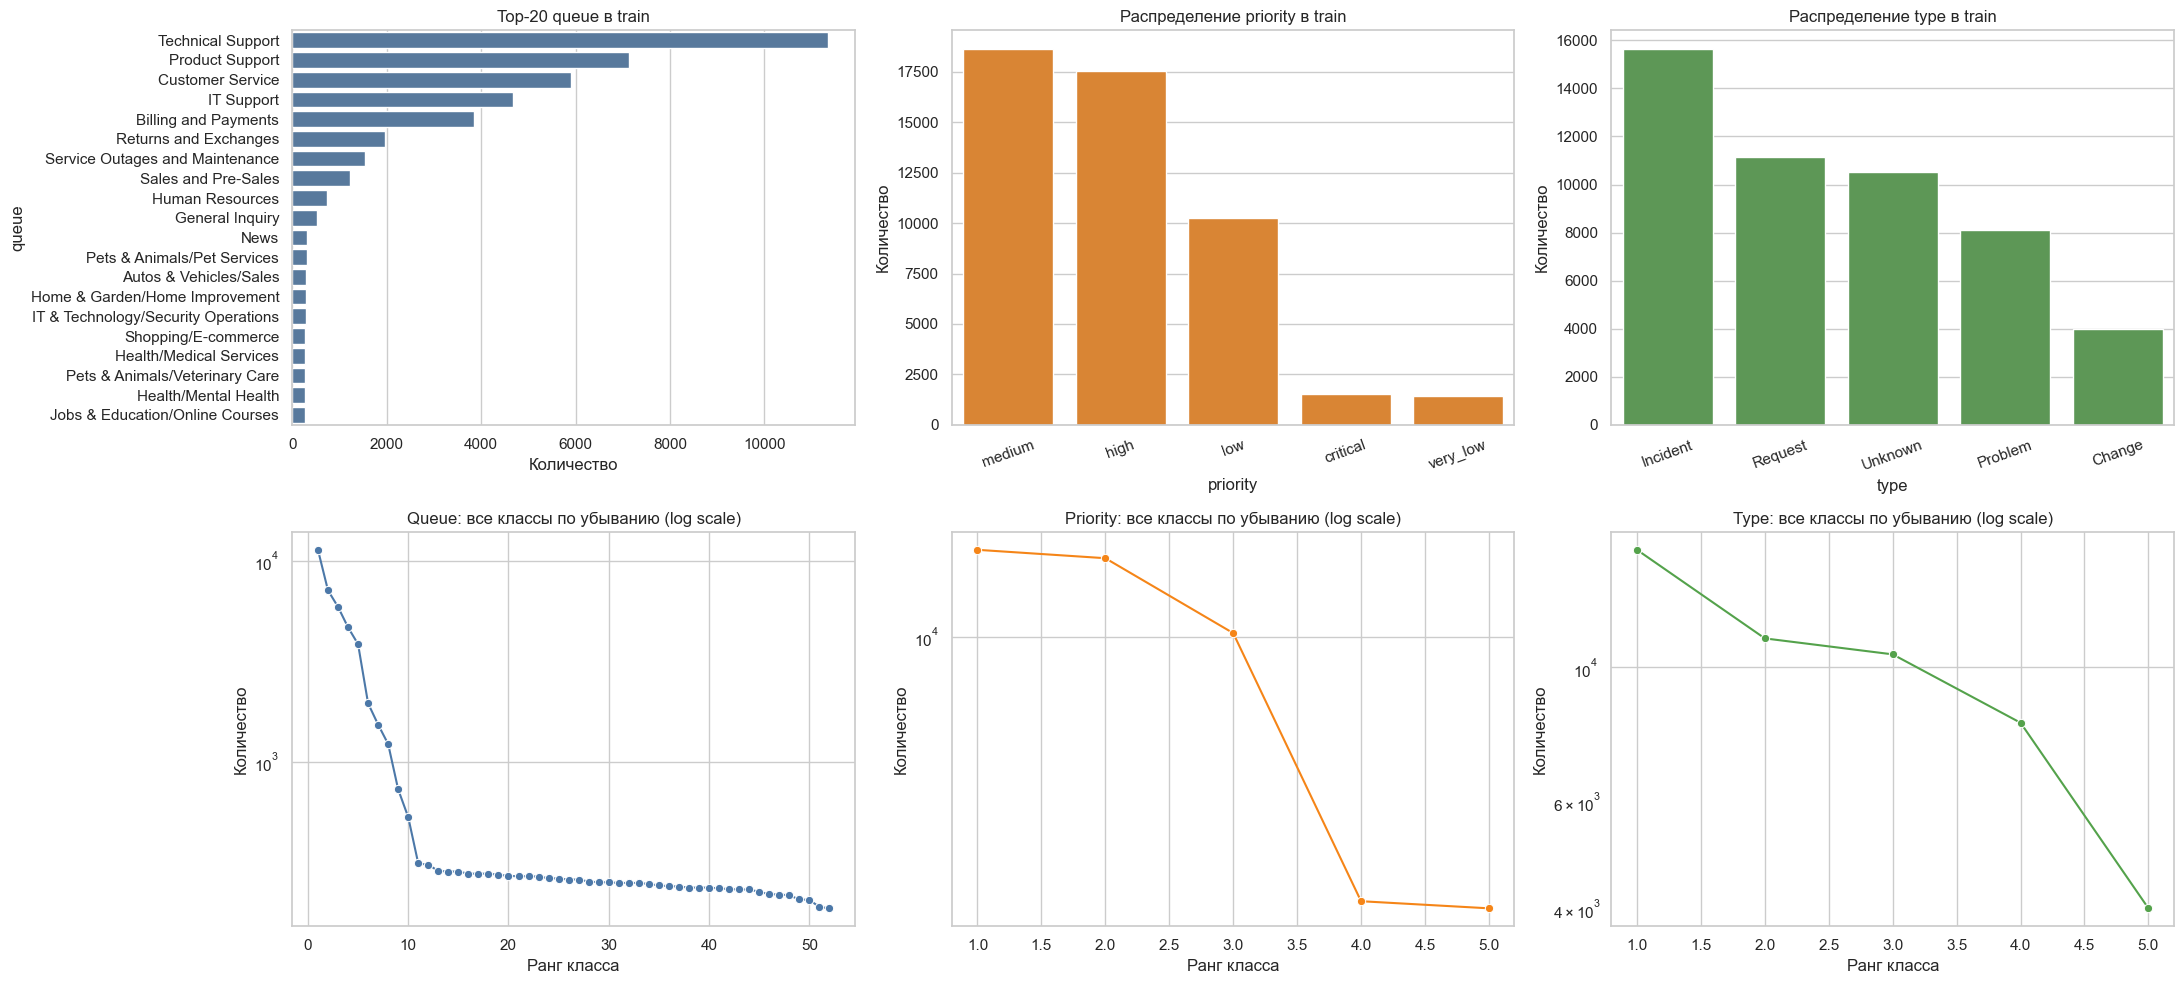

,target,n_classes,max_count,min_count,max_min_ratio
0,queue,52,11354,187,60.72
1,priority,5,18629,1441,12.93
2,type,5,15632,4004,3.90


In [6]:
def prepare_train_counts(dist_df, label_col):
    train = (
        dist_df[dist_df["split"] == "train"]
        .sort_values("count", ascending=False)
        .reset_index(drop=True)
        .copy()
    )
    train["rank"] = np.arange(1, len(train) + 1)
    train["share"] = train["count"] / train["count"].sum()
    return train

queue_train = prepare_train_counts(queue_dist, "queue")
priority_train = prepare_train_counts(priority_dist, "priority")
type_train = prepare_train_counts(type_dist, "type")

fig, axes = plt.subplots(2, 3, figsize=(22, 10))

# 1 ряд: обычные распределения
sns.barplot(data=queue_train.head(20), x="count", y="queue", ax=axes[0, 0], color="#4C78A8")
axes[0, 0].set_title("Top-20 queue в train")
axes[0, 0].set_xlabel("Количество")
axes[0, 0].set_ylabel("queue")

sns.barplot(data=priority_train, x="priority", y="count", ax=axes[0, 1], color="#F58518")
axes[0, 1].set_title("Распределение priority в train")
axes[0, 1].set_xlabel("priority")
axes[0, 1].set_ylabel("Количество")
axes[0, 1].tick_params(axis="x", rotation=20)

sns.barplot(data=type_train, x="type", y="count", ax=axes[0, 2], color="#54A24B")
axes[0, 2].set_title("Распределение type в train")
axes[0, 2].set_xlabel("type")
axes[0, 2].set_ylabel("Количество")
axes[0, 2].tick_params(axis="x", rotation=20)

# 2 ряд: все классы по рангу, чтобы был виден хвост
sns.lineplot(data=queue_train, x="rank", y="count", marker="o", ax=axes[1, 0], color="#4C78A8")
axes[1, 0].set_yscale("log")
axes[1, 0].set_title("Queue: все классы по убыванию (log scale)")
axes[1, 0].set_xlabel("Ранг класса")
axes[1, 0].set_ylabel("Количество")

sns.lineplot(data=priority_train, x="rank", y="count", marker="o", ax=axes[1, 1], color="#F58518")
axes[1, 1].set_yscale("log")
axes[1, 1].set_title("Priority: все классы по убыванию (log scale)")
axes[1, 1].set_xlabel("Ранг класса")
axes[1, 1].set_ylabel("Количество")

sns.lineplot(data=type_train, x="rank", y="count", marker="o", ax=axes[1, 2], color="#54A24B")
axes[1, 2].set_yscale("log")
axes[1, 2].set_title("Type: все классы по убыванию (log scale)")
axes[1, 2].set_xlabel("Ранг класса")
axes[1, 2].set_ylabel("Количество")

plt.tight_layout()
plt.show()

imbalance_table = pd.DataFrame(
    [
        {
            "target": "queue",
            "n_classes": len(queue_train),
            "max_count": int(queue_train["count"].max()),
            "min_count": int(queue_train["count"].min()),
            "max_min_ratio": round(queue_train["count"].max() / queue_train["count"].min(), 2),
        },
        {
            "target": "priority",
            "n_classes": len(priority_train),
            "max_count": int(priority_train["count"].max()),
            "min_count": int(priority_train["count"].min()),
            "max_min_ratio": round(priority_train["count"].max() / priority_train["count"].min(), 2),
        },
        {
            "target": "type",
            "n_classes": len(type_train),
            "max_count": int(type_train["count"].max()),
            "min_count": int(type_train["count"].min()),
            "max_min_ratio": round(type_train["count"].max() / type_train["count"].min(), 2),
        },
    ]
)

display(imbalance_table)


In [7]:
p90_words = length_df.loc[length_df['split'] == 'train', 'words_p90'].iloc[0]
language_mix = language_df.query("split == 'train'")[["language", "share"]]
display(Markdown(
    f"""
В train есть смесь двух языков: английского и немецкого. Значит, monolingual-модель здесь была бы плохим выбором.

У текстов умеренная длина: 90-й перцентиль по словам в train равен **{p90_words:.0f}**. Дальше главным ориентиром остаётся `Macro-F1(queue)`, потому что именно эта метрика указана в ТЗ как основная и входит в итоговый score с весом `0.70`.
"""
))


В train есть смесь двух языков: английского и немецкого. Значит, monolingual-модель здесь была бы плохим выбором.

У текстов умеренная длина: 90-й перцентиль по словам в train равен **99**. Дальше главным ориентиром остаётся `Macro-F1(queue)`, потому что именно эта метрика указана в ТЗ как основная и входит в итоговый score с весом `0.70`.


## 3. Базовые модели

In [8]:

baseline_table = pd.read_csv(BASELINE_DIR / 'baseline_comparison.csv')
linear_table = pd.read_csv(BASELINE_DIR / 'linear_summary.csv')
knn_table = pd.read_csv(BASELINE_DIR / 'knn_summary.csv')

display(linear_table)
display(knn_table)
display(baseline_table)


,split,model_name,queue_acc,queue_macro_f1,priority_acc,type_acc,score
0,val,tfidf_linear_svc,0.687662,0.897916,0.721179,0.893135,0.870688
1,test,tfidf_linear_svc,0.693702,0.895992,0.713615,0.899790,0.869205


,split,model_name,queue_acc,queue_macro_f1
0,val,tfidf_svd_knn_queue,0.568491,0.542816
1,test,tfidf_svd_knn_queue,0.555286,0.531326


,split,model_name,queue_acc,queue_macro_f1,priority_acc,type_acc,score
0,val,tfidf_linear_svc,0.687662,0.897916,0.721179,0.893135,0.870688
1,test,tfidf_linear_svc,0.693702,0.895992,0.713615,0.899790,0.869205
2,val,tfidf_svd_knn_queue,0.568491,0.542816,NaN,NaN,NaN
3,test,tfidf_svd_knn_queue,0.555286,0.531326,NaN,NaN,NaN


In [9]:

linear_test = linear_table.query("split == 'test'").iloc[0]
knn_test = knn_table.query("split == 'test'").iloc[0]
display(Markdown(
    f"""
`TF-IDF + LinearSVC` оказался сильным baseline: на test он даёт `Macro-F1(queue)` = **{linear_test['queue_macro_f1']:.4f}**, `Accuracy(priority)` = **{linear_test['priority_acc']:.4f}**, `Accuracy(type)` = **{linear_test['type_acc']:.4f}**, итоговый score = **{linear_test['score']:.4f}**.

`TF-IDF + SVD + KNN` заметно слабее по `queue`, поэтому как основной классический ориентир дальше использую именно линейную модель.
"""
))



`TF-IDF + LinearSVC` оказался сильным baseline: на test он даёт `Macro-F1(queue)` = **0.8960**, `Accuracy(priority)` = **0.7136**, `Accuracy(type)` = **0.8998**, итоговый score = **0.8692**.

`TF-IDF + SVD + KNN` заметно слабее по `queue`, поэтому как основной классический ориентир дальше использую именно линейную модель.


## 4. Transformer-модели

In [10]:
mt_base_metrics = load_json(MT_BASE_DIR / 'metrics.json')
mt_balanced_metrics = load_json(MT_BALANCED_DIR / 'metrics.json')
queue_only_metrics = load_json(QUEUE_ONLY_DIR / 'metrics.json')
mmbert_base_metrics = load_json(MMBERT_BASE_DIR / 'metrics.json')

mt_base_history = pd.read_csv(MT_BASE_DIR / 'history.csv')
mt_balanced_history = pd.read_csv(MT_BALANCED_DIR / 'history.csv')
queue_only_history = pd.read_csv(QUEUE_ONLY_DIR / 'history.csv')
mmbert_base_history = pd.read_csv(MMBERT_BASE_DIR / 'history.csv')

transformer_configs = pd.DataFrame([
    {
        'model_name': 'xlm-r multitask base',
        'backbone': mt_base_metrics['config']['model_name'],
        'tasks': 'queue, priority, type',
        'max_length': mt_base_metrics['config']['max_length'],
        'epochs': mt_base_metrics['config']['epochs'],
        'batch_size': mt_base_metrics['config']['batch_size'],
        'grad_accum': mt_base_metrics['config']['grad_accum_steps'],
        'effective_batch': mt_base_metrics['config']['batch_size'] * mt_base_metrics['config']['grad_accum_steps'],
        'learning_rate': mt_base_metrics['config']['learning_rate'],
        'weight_decay': mt_base_metrics['config']['weight_decay'],
        'warmup_ratio': mt_base_metrics['config']['warmup_ratio'],
        'train_last_n_layers': mt_base_metrics.get('train_last_n_layers'),
        'gradient_checkpointing': mt_base_metrics['config']['gradient_checkpointing'],
        'seed': mt_base_metrics['config']['seed'],
    },
    {
        'model_name': 'xlm-r multitask balanced',
        'backbone': mt_balanced_metrics['config']['model_name'],
        'tasks': 'queue, priority, type',
        'max_length': mt_balanced_metrics['config']['max_length'],
        'epochs': mt_balanced_metrics['config']['epochs'],
        'batch_size': mt_balanced_metrics['config']['batch_size'],
        'grad_accum': mt_balanced_metrics['config']['grad_accum_steps'],
        'effective_batch': mt_balanced_metrics['config']['batch_size'] * mt_balanced_metrics['config']['grad_accum_steps'],
        'learning_rate': mt_balanced_metrics['config']['learning_rate'],
        'weight_decay': mt_balanced_metrics['config']['weight_decay'],
        'warmup_ratio': mt_balanced_metrics['config']['warmup_ratio'],
        'train_last_n_layers': mt_balanced_metrics.get('train_last_n_layers'),
        'gradient_checkpointing': mt_balanced_metrics['config']['gradient_checkpointing'],
        'seed': mt_balanced_metrics['config']['seed'],
    },
    {
        'model_name': 'mmbert multitask base',
        'backbone': mmbert_base_metrics['config']['model_name'],
        'tasks': 'queue, priority, type',
        'max_length': mmbert_base_metrics['config']['max_length'],
        'epochs': mmbert_base_metrics['config']['epochs'],
        'batch_size': mmbert_base_metrics['config']['batch_size'],
        'grad_accum': mmbert_base_metrics['config']['grad_accum_steps'],
        'effective_batch': mmbert_base_metrics['config']['batch_size'] * mmbert_base_metrics['config']['grad_accum_steps'],
        'learning_rate': mmbert_base_metrics['config']['learning_rate'],
        'weight_decay': mmbert_base_metrics['config']['weight_decay'],
        'warmup_ratio': mmbert_base_metrics['config']['warmup_ratio'],
        'train_last_n_layers': mmbert_base_metrics.get('train_last_n_layers'),
        'gradient_checkpointing': mmbert_base_metrics['config']['gradient_checkpointing'],
        'seed': mmbert_base_metrics['config']['seed'],
    },
    {
        'model_name': 'xlm-r queue only',
        'backbone': queue_only_metrics['config']['model_name'],
        'tasks': 'queue',
        'max_length': queue_only_metrics['config']['max_length'],
        'epochs': queue_only_metrics['config']['epochs'],
        'batch_size': queue_only_metrics['config']['batch_size'],
        'grad_accum': queue_only_metrics['config']['grad_accum_steps'],
        'effective_batch': queue_only_metrics['config']['batch_size'] * queue_only_metrics['config']['grad_accum_steps'],
        'learning_rate': queue_only_metrics['config']['learning_rate'],
        'weight_decay': queue_only_metrics['config']['weight_decay'],
        'warmup_ratio': queue_only_metrics['config']['warmup_ratio'],
        'train_last_n_layers': queue_only_metrics.get('train_last_n_layers'),
        'gradient_checkpointing': queue_only_metrics['config']['gradient_checkpointing'],
        'seed': queue_only_metrics['config']['seed'],
    },
])

display(Markdown('### Конфигурации transformer-экспериментов'))
display(transformer_configs)

transformer_table = pd.DataFrame([
    {'model_name': 'xlm-r multitask base', **mt_base_metrics['test_metrics']},
    {'model_name': 'xlm-r multitask balanced', **mt_balanced_metrics['test_metrics']},
    {'model_name': 'mmbert multitask base', **mmbert_base_metrics['test_metrics']},
    {'model_name': 'xlm-r queue only', **queue_only_metrics['test_metrics']},
])

transformer_table = transformer_table.sort_values('score', ascending=False, na_position='last')
display(transformer_table)


### Конфигурации transformer-экспериментов

,model_name,backbone,tasks,max_length,epochs,batch_size,grad_accum,effective_batch,learning_rate,weight_decay,warmup_ratio,train_last_n_layers,gradient_checkpointing,seed
0,xlm-r multitask base,FacebookAI/xlm-roberta-base,"queue, priority, type",192,3,32,1,32,0.00002,0.01,0.1,2,True,42
1,xlm-r multitask balanced,FacebookAI/xlm-roberta-base,"queue, priority, type",256,1,8,4,32,0.00002,0.01,0.1,2,False,42
2,mmbert multitask base,jhu-clsp/mmBERT-base,"queue, priority, type",192,3,8,1,8,0.00002,0.01,0.1,2,True,42
3,xlm-r queue only,FacebookAI/xlm-roberta-base,queue,256,1,8,4,32,0.00002,0.01,0.1,2,False,42


,model_name,queue_acc,queue_macro_f1,priority_acc,type_acc,score
2,mmbert multitask base,0.542496,0.767471,0.539097,0.843452,0.744612
0,xlm-r multitask base,0.497005,0.665439,0.490044,0.817063,0.661873
1,xlm-r multitask balanced,0.363283,0.513752,0.422535,0.740327,0.534056
3,xlm-r queue only,0.316982,0.037158,NaN,NaN,NaN


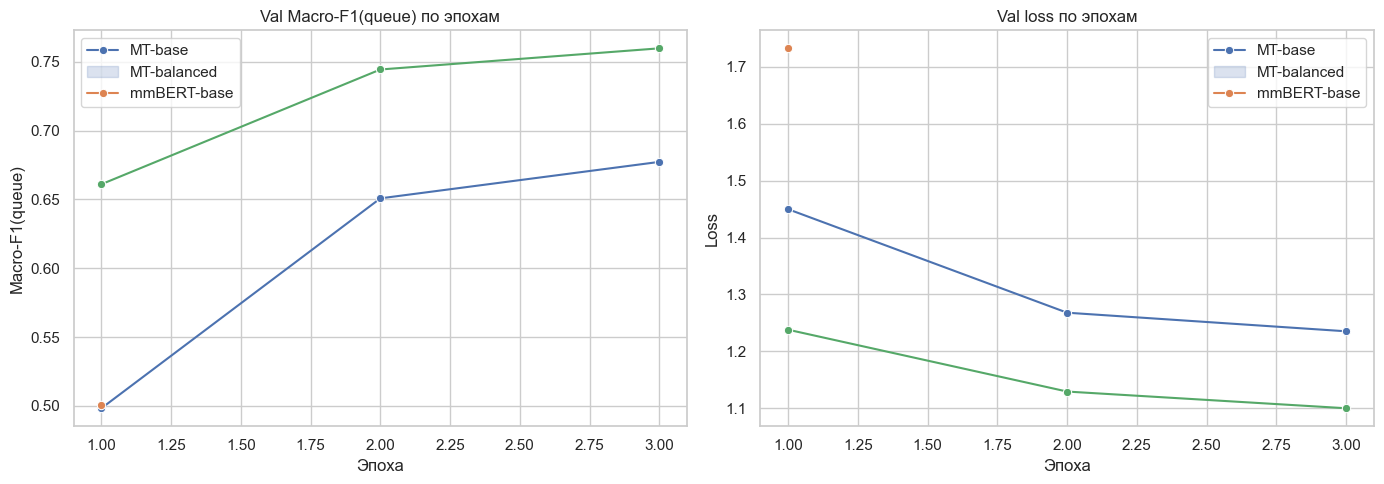

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(data=mt_base_history, x='epoch', y='queue_macro_f1', marker='o', ax=axes[0])
sns.lineplot(data=mt_balanced_history, x='epoch', y='queue_macro_f1', marker='o', ax=axes[0])
sns.lineplot(data=mmbert_base_history, x='epoch', y='queue_macro_f1', marker='o', ax=axes[0])
axes[0].set_title('Val Macro-F1(queue) по эпохам')
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Macro-F1(queue)')
axes[0].legend(['MT-base', 'MT-balanced', 'mmBERT-base'])

sns.lineplot(data=mt_base_history, x='epoch', y='val_loss', marker='o', ax=axes[1])
sns.lineplot(data=mt_balanced_history, x='epoch', y='val_loss', marker='o', ax=axes[1])
sns.lineplot(data=mmbert_base_history, x='epoch', y='val_loss', marker='o', ax=axes[1])
axes[1].set_title('Val loss по эпохам')
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Loss')
axes[1].legend(['MT-base', 'MT-balanced', 'mmBERT-base'])

plt.tight_layout()
plt.show()

In [12]:
multitask_candidates = [
    ('xlm-r multitask base', mt_base_metrics, MT_BASE_DIR),
    ('xlm-r multitask balanced', mt_balanced_metrics, MT_BALANCED_DIR),
    ('mmbert multitask base', mmbert_base_metrics, MMBERT_BASE_DIR),
]

best_multitask_name, best_multitask_metrics, best_multitask_dir = max(
    multitask_candidates,
    key=lambda item: item[1]['val_metrics'].get('queue_macro_f1', -1.0),
)

token_quantiles = load_json(best_multitask_dir / 'token_length_quantiles.json')
train_last_n_layers = best_multitask_metrics.get('train_last_n_layers')
trainable_params = best_multitask_metrics.get('trainable_params')
best_model_name = best_multitask_metrics['config']['model_name']

display(Markdown(
    f"""
Для transformer-части я сравнил два multilingual encoder-а: `FacebookAI/xlm-roberta-base` и более свежий `jhu-clsp/mmBERT-base`.

Лучшей multitask-конфигурацией по валидации стала **{best_multitask_name}** на backbone `{best_model_name}`. В этом режиме дообучаются последние **{train_last_n_layers}** encoder-слоя и три классификационные головы.

Число trainable-параметров в этом режиме равно **{trainable_params:,}**.

По токенам 90-й перцентиль в train для этой конфигурации равен **{token_quantiles['q90']:.0f}**, так что длины `max_length = {best_multitask_metrics['config']['max_length']}` достаточно для основной массы тикетов.

Для calibration и coverage-анализа ниже использую именно эту лучшую multitask-модель.
"""
))


Для transformer-части я сравнил два multilingual encoder-а: `FacebookAI/xlm-roberta-base` и более свежий `jhu-clsp/mmBERT-base`.

Лучшей multitask-конфигурацией по валидации стала **mmbert multitask base** на backbone `jhu-clsp/mmBERT-base`. В этом режиме дообучаются последние **2** encoder-слоя и три классификационные головы.

Число trainable-параметров в этом режиме равно **10,077,758**.

По токенам 90-й перцентиль в train для этой конфигурации равен **155**, так что длины `max_length = 192` достаточно для основной массы тикетов.

Для calibration и coverage-анализа ниже использую именно эту лучшую multitask-модель.



Для реализации classification я опираюсь на официальный сценарий Hugging Face для sequence classification, а для запуска на Mac использую MPS backend PyTorch. Для confidence-блока полезны и более свежие материалы 2026 года по calibration и selective prediction, потому что простой softmax-confidence не всегда надёжен: [Transformers sequence classification](https://huggingface.co/docs/transformers/en/tasks/sequence_classification), [PyTorch MPS backend](https://docs.pytorch.org/docs/stable/notes/mps), [An Empirical Analysis of Calibration and Selective Prediction in Multimodal Clinical Condition Classification, 2026](https://arxiv.org/abs/2603.02719), [Selective Prior Synchronization via SYNC Loss, 2026](https://arxiv.org/abs/2602.11316).


## 5. Calibration, confidence и coverage

In [13]:
calibration_table = pd.read_csv(best_multitask_dir / 'calibration_metrics.csv')
coverage_table = pd.read_csv(best_multitask_dir / 'coverage_table.csv')
coverage_grid = pd.read_csv(best_multitask_dir / 'coverage_grid.csv')

coverage_display = coverage_table[
    [
        'coverage',
        'auto_rows',
        'manual_rows',
        'auto_queue_macro_f1',
        'auto_priority_acc',
        'auto_type_acc',
        'auto_score',
        'oracle_score',
    ]
].copy()

display(Markdown(f"Ниже calibration и coverage для **{best_multitask_name}**."))
display(calibration_table)
display(coverage_display)


Ниже calibration и coverage для **mmbert multitask base**.

,task,temperature,ece_before,ece_after,nll_before,nll_after
0,queue,0.909430,0.037350,0.023123,1.303055,1.298318
1,priority,0.885654,0.019491,0.029789,0.935137,0.932668
2,type,0.895091,0.012661,0.012582,0.317233,0.315783


,coverage,auto_rows,manual_rows,auto_queue_macro_f1,auto_priority_acc,auto_type_acc,auto_score,oracle_score
0,0.50,3088,3089,0.814095,0.614961,0.871114,0.792777,0.895727
1,0.60,3706,2471,0.803112,0.597140,0.853211,0.779731,0.868961
2,0.70,4324,1853,0.794408,0.580019,0.845051,0.769846,0.842464
3,0.80,4942,1235,0.785016,0.565156,0.837515,0.759912,0.811372
4,0.90,5559,618,0.779364,0.549559,0.839539,0.753920,0.781687
5,0.95,5868,309,0.776362,0.544138,0.842195,0.751403,0.765400
6,1.00,6177,0,0.767471,0.539097,0.843452,0.744612,0.744612


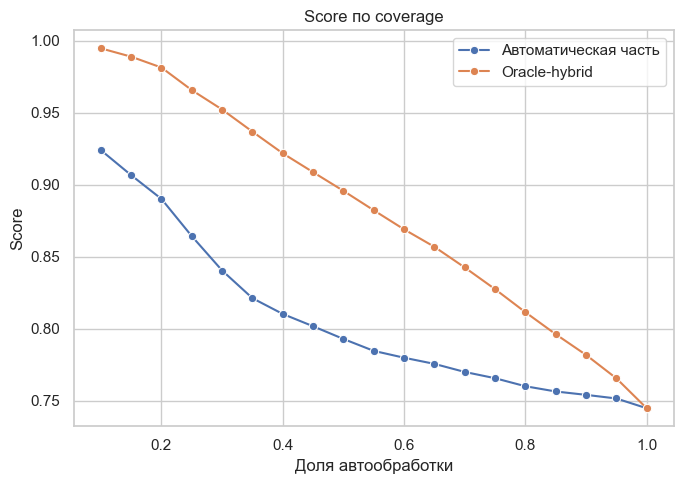

In [14]:
plt.figure(figsize=(7, 5))

sns.lineplot(data=coverage_grid, x='coverage', y='auto_score', marker='o', label='Автоматическая часть')
sns.lineplot(data=coverage_grid, x='coverage', y='oracle_score', marker='o', label='Oracle-hybrid')
plt.title('Score по coverage')
plt.xlabel('Доля автообработки')
plt.ylabel('Score')
plt.tight_layout()
plt.show()


In [15]:
best_quality_row = coverage_table.sort_values('auto_score', ascending=False).iloc[0]
full_coverage_row = coverage_table.loc[coverage_table['coverage'] == coverage_table['coverage'].max()].iloc[0]

display(Markdown(
    f"""
После temperature scaling можно ранжировать тикеты по confidence уже аккуратнее.

Максимальный score на автоматически обработанной части достигается при coverage **{best_quality_row['coverage']:.0%}** и равен **{best_quality_row['auto_score']:.3f}**. Если отдавать модели весь поток, score снижается до **{full_coverage_row['auto_score']:.3f}**.

Это показывает, что самые уверенные тикеты действительно проще для модели, а при расширении автообработки в поток попадает всё больше сложных случаев.
"""
))



После temperature scaling можно ранжировать тикеты по confidence уже аккуратнее.

Максимальный score на автоматически обработанной части достигается при coverage **50%** и равен **0.793**. Если отдавать модели весь поток, score снижается до **0.745**.

Это показывает, что самые уверенные тикеты действительно проще для модели, а при расширении автообработки в поток попадает всё больше сложных случаев.


## 6. Сводная таблица результатов

In [16]:
final_rows = []
final_rows.extend(linear_table.to_dict(orient='records'))
final_rows.extend(knn_table.to_dict(orient='records'))
final_rows.append({'split': 'test', 'model_name': 'xlm-r multitask base', **mt_base_metrics['test_metrics']})
final_rows.append({'split': 'test', 'model_name': 'xlm-r multitask balanced', **mt_balanced_metrics['test_metrics']})
final_rows.append({'split': 'test', 'model_name': 'mmbert multitask base', **mmbert_base_metrics['test_metrics']})
final_rows.append({'split': 'test', 'model_name': 'xlm-r queue only', **queue_only_metrics['test_metrics']})

final_table = pd.DataFrame(final_rows)
display(final_table)

,split,model_name,queue_acc,queue_macro_f1,priority_acc,type_acc,score
0,val,tfidf_linear_svc,0.687662,0.897916,0.721179,0.893135,0.870688
1,test,tfidf_linear_svc,0.693702,0.895992,0.713615,0.899790,0.869205
2,val,tfidf_svd_knn_queue,0.568491,0.542816,NaN,NaN,NaN
3,test,tfidf_svd_knn_queue,0.555286,0.531326,NaN,NaN,NaN
4,test,xlm-r multitask base,0.497005,0.665439,0.490044,0.817063,0.661873
5,test,xlm-r multitask balanced,0.363283,0.513752,0.422535,0.740327,0.534056
6,test,mmbert multitask base,0.542496,0.767471,0.539097,0.843452,0.744612
7,test,xlm-r queue only,0.316982,0.037158,NaN,NaN,NaN


In [17]:
best_row = final_table.query("split == 'test'").sort_values('score', ascending=False, na_position='last').iloc[0]
if any(tag in best_row['model_name'] for tag in ['xlm-r', 'mmbert']):
    model_comment = 'В моём прогоне transformer дал лучший общий результат и дополнительно позволяет построить единый confidence-сигнал для сценария частичной автоматизации.'
else:
    model_comment = 'В моём прогоне сильнее оказался baseline на TF-IDF. Для коротких служебных текстов это нормальная ситуация: линейная модель по n-граммам остаётся очень сильной отправной точкой даже рядом с transformer-подходом.'

display(Markdown(
    f"""
Лучший итоговый результат на test показала модель **{best_row['model_name']}**.

{model_comment}

Главный практический вывод здесь не только про одно число в leaderboard. Гораздо полезнее смотреть, как ведёт себя качество на самых уверенных предсказаниях и что происходит, если часть тикетов отправлять на ручную проверку. Именно это связывает обычные метрики классификации с реальным процессом обработки тикетов.
"""
))


Лучший итоговый результат на test показала модель **tfidf_linear_svc**.

В моём прогоне сильнее оказался baseline на TF-IDF. Для коротких служебных текстов это нормальная ситуация: линейная модель по n-граммам остаётся очень сильной отправной точкой даже рядом с transformer-подходом.

Главный практический вывод здесь не только про одно число в leaderboard. Гораздо полезнее смотреть, как ведёт себя качество на самых уверенных предсказаниях и что происходит, если часть тикетов отправлять на ручную проверку. Именно это связывает обычные метрики классификации с реальным процессом обработки тикетов.
